# Analisis Defek Keramik — Refactored
> Notebook ini adalah versi yang sudah dioptimasi dan direfaktor dari `TEST_PIRING_KERAMIK.ipynb`.
> Semua bug, inefisiensi, dan inkonsistensi telah diperbaiki.

In [ ]:
# Standard Library
from collections import defaultdict
import os
import re
from pathlib import Path

# Third-Party
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

# Deep Learning
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms


/home/artha/Documents/code/CeramicPlateDefectDetector/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Konfigurasi & Konstanta Global
Semua konstanta dan pola regex didefinisikan di satu tempat agar konsisten antara tahap EDA dan training.

In [2]:
# ── PATH DATASET ──────────────────────────────────────────────────────────────
DATASET_PATH = Path("dataset")

# ── EKSTENSI GAMBAR (tuple, bukan string) ──────────────────────────────────────
# FIX #1: exts = ('.jpg') adalah string biasa, bukan tuple.
# Gunakan tuple eksplisit agar bisa ditambah ekstensi lain dengan mudah.
IMAGE_EXTS = ('.jpg', '.jpeg', '.png')

# ── POLA DEFEK — SATU DEFINISI UNTUK EDA & TRAINING ───────────────────────────
# FIX #2: Sebelumnya ada dua versi DEFECT_PATTERNS yang berbeda (anchored vs unanchored)
# di sel EDA dan sel training, menyebabkan klasifikasi yang tidak konsisten.
# Kini ada satu definisi tunggal: folder-first, lalu nama file, dengan pola unanchored.
DEFECT_PATTERNS = {
    'crack'  : re.compile(r'crack',   re.IGNORECASE),
    'spot'   : re.compile(r'spot',    re.IGNORECASE),
    'pinhole': re.compile(r'pinhole', re.IGNORECASE),
}
DEFECT_TYPES = ['crack', 'spot', 'pinhole', 'unknown']
MAIN_TYPES   = ['crack', 'spot', 'pinhole']

CATEGORY_COLORS = {
    'crack'  : '#e74c3c',
    'spot'   : '#f39c12',
    'pinhole': '#3498db',
    'unknown': '#95a5a6',
}


## 2. Helper Functions
Semua fungsi utilitas dipisahkan di satu blok agar mudah di-test dan di-reuse.

In [3]:
def collect_image_paths(root, exts=IMAGE_EXTS):
    """Kumpulkan semua path gambar secara rekursif menggunakan Path.rglob.

    FIX #5: Sebelumnya ada dua cara pengumpulan gambar yang berbeda:
    - Cell 1 memakai Path.glob (flat, tidak rekursif)
    - Cell 2 memakai os.walk (rekursif, tapi verbose)
    Kini disatukan dengan Path.rglob yang lebih Pythonic dan ringkas.
    """
    root = Path(root)
    return sorted(str(p) for ext in exts for p in root.rglob(f'*{ext}'))


def threshold_otsu(gray):
    """Hitung threshold Otsu dan kembalikan gambar biner.

    FIX #4: measure_crack_thickness dan get_contour_lengths keduanya memanggil
    cv2.threshold dengan parameter identik secara terpisah. Dengan memisahkan
    operasi ini, kita bisa menghitung biner sekali dan membagikannya ke kedua
    fungsi, menghindari komputasi ganda per gambar.
    """
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return binary


def measure_crack_thickness(binary):
    """Hitung ketebalan rata-rata garis retak dari gambar biner."""
    if binary.sum() == 0 or np.all(binary == 255):
        return 0.0
    dist    = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    nonzero = dist[dist > 0]
    return float(np.mean(nonzero) * 2) if len(nonzero) > 0 else 0.0


def get_contour_lengths(binary):
    """Ukur panjang semua kontur dari gambar biner."""
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return [
        cv2.arcLength(cnt, closed=False)
        for cnt in contours
        if cv2.arcLength(cnt, closed=False) > 0
    ]


def is_blank(gray, threshold=10):
    """Deteksi apakah gambar hitam, putih, atau abu-abu solid."""
    mean_val = np.mean(gray)
    std_val  = np.std(gray)
    if std_val < threshold:
        if mean_val < 30:
            return 'HITAM'
        elif mean_val > 225:
            return 'PUTIH'
        return 'SOLID (abu-abu)'
    return None


def classify_by_path(filepath):
    """Klasifikasi defek berdasarkan nama folder (prioritas) atau nama file.

    FIX #2 (lanjutan): Fungsi ini menggantikan classify_by_filename (EDA)
    dan classify_by_path (training) menjadi satu implementasi tunggal.
    """
    filepath = Path(filepath)
    # Prioritas 1: nama folder induk
    for defect_type, pattern in DEFECT_PATTERNS.items():
        if pattern.search(filepath.parent.name):
            return defect_type
    # Prioritas 2: nama file
    for defect_type, pattern in DEFECT_PATTERNS.items():
        if pattern.search(filepath.name):
            return defect_type
    return 'unknown'


## 3. EDA — Analisis Dataset
**PASS-1**: Deteksi gambar blank.  
**PASS-2**: Analisis utama dengan satu kali baca per gambar (termasuk cache white pixel count untuk Plot 4).

In [4]:
image_paths = collect_image_paths(DATASET_PATH)
print(f"Total gambar ditemukan: {len(image_paths)}")

# ── PASS-1: DETEKSI BLANK ─────────────────────────────────────────────────────
print("\n[PASS-1] Mendeteksi gambar blank...")
blank_images = []

for path in image_paths:
    img = cv2.imread(path)
    if img is None:
        continue
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blank_type = is_blank(gray)
    if blank_type:
        blank_images.append((os.path.basename(path), blank_type))

blank_filenames = {fname for fname, _ in blank_images}
image_paths     = [p for p in image_paths if os.path.basename(p) not in blank_filenames]
print(f"Gambar blank ditemukan  : {len(blank_images)}")
print(f"Total gambar valid      : {len(image_paths)}")

# ── PASS-2: ANALISIS UTAMA ────────────────────────────────────────────────────
# FIX #3 & #4: Semua metrik dihitung dalam satu loop — termasuk white_pixels
# yang sebelumnya dihitung ulang dengan membaca semua file lagi di Plot 4.
print("\n[PASS-2] Menganalisis gambar valid...")
all_thicknesses      = []
total_defects        = defaultdict(int)
per_image_results    = []
lengths_per_category = {k: [] for k in DEFECT_TYPES}

for path in tqdm(image_paths, desc="Analisis"):
    img = cv2.imread(path)
    if img is None:
        print(f"[SKIP] Tidak bisa dibaca: {path}")
        continue

    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    filename = os.path.basename(path)

    # Hitung biner sekali, gunakan untuk semua operasi (FIX #4)
    binary      = threshold_otsu(gray)
    thickness   = measure_crack_thickness(binary)
    lengths     = get_contour_lengths(binary)
    white_count = int(np.sum(binary == 255))  # cache untuk Plot 4 (FIX #3)

    defect_type = classify_by_path(path) or 'unknown'

    all_thicknesses.append(thickness)
    total_defects[defect_type] += 1
    lengths_per_category[defect_type].extend(lengths)

    per_image_results.append({
        'file'        : filename,
        'thickness'   : round(thickness, 2),
        'defect'      : defect_type,
        'white_pixels': white_count,
    })

# ── LAPORAN ───────────────────────────────────────────────────────────────────
valid_thick = [t for t in all_thicknesses if t > 0]
avg_thick   = np.mean(valid_thick) if valid_thick else 0.0

print("\n" + "="*60)
print("            HASIL ANALISIS DATASET DEFEK")
print("="*60)
print(f"\n[1] KETEBALAN RATA-RATA GARIS RETAK")
print(f"    → {avg_thick:.2f} pixel  (dari {len(valid_thick)} gambar berisi retak)")

print(f"\n[2] GAMBAR BLANK (dikeluarkan dari analisis)")
if blank_images:
    print(f"    → {len(blank_images)} gambar ditemukan:")
    for fname, btype in blank_images:
        print(f"       • {fname}  [{btype}]")
else:
    print("    → Tidak ada gambar blank.")

print(f"\n[3] JUMLAH DEFEK BERDASARKAN NAMA FILE")
print(f"    Pola: crack | spot | pinhole (folder atau nama file)")
print(f"    {'Jenis':<10} {'Jumlah':>8}")
print(f"    {'-'*20}")
for dtype in DEFECT_TYPES:
    if total_defects[dtype] > 0:
        print(f"    {dtype:<10} {total_defects[dtype]:>8}")
print(f"    {'-'*20}")
print(f"    {'TOTAL':<10} {sum(total_defects.values()):>8}")

print(f"\n[4] DISTRIBUSI PANJANG KONTUR PER KATEGORI (pixel)")
print(f"    {'Kategori':<10} {'Jml Kontur':>12} {'Min':>8} {'Max':>8} {'Rata-rata':>10} {'Median':>8}")
print(f"    {'-'*60}")
for dtype in DEFECT_TYPES:
    lens = lengths_per_category[dtype]
    if lens:
        print(f"    {dtype:<10} {len(lens):>12} {min(lens):>8.1f} {max(lens):>8.1f} "
              f"{np.mean(lens):>10.1f} {np.median(lens):>8.1f}")
    else:
        print(f"    {dtype:<10} {'0':>12} {'-':>8} {'-':>8} {'-':>10} {'-':>8}")


Total gambar ditemukan: 12483

[PASS-1] Mendeteksi gambar blank...
Gambar blank ditemukan  : 12
Total gambar valid      : 12471

[PASS-2] Menganalisis gambar valid...


Analisis: 100%|██████████| 12471/12471 [00:26<00:00, 477.91it/s]


            HASIL ANALISIS DATASET DEFEK

[1] KETEBALAN RATA-RATA GARIS RETAK
    → 74.81 pixel  (dari 12471 gambar berisi retak)

[2] GAMBAR BLANK (dikeluarkan dari analisis)
    → 12 gambar ditemukan:
       • crack.112.jpg  [HITAM]
       • crack.1724.jpg  [HITAM]
       • crack.2088.jpg  [HITAM]
       • crack.2264.jpg  [HITAM]
       • crack.2321.jpg  [HITAM]
       • crack.2392.jpg  [HITAM]
       • crack.3313.jpg  [HITAM]
       • crack.3634.jpg  [HITAM]
       • crack.4255.jpg  [HITAM]
       • crack.4515.jpg  [HITAM]
       • crack.5273.jpg  [HITAM]
       • crack.5444.jpg  [HITAM]

[3] JUMLAH DEFEK BERDASARKAN NAMA FILE
    Pola: crack | spot | pinhole (folder atau nama file)
    Jenis        Jumlah
    --------------------
    crack          5903
    spot           6568
    --------------------
    TOTAL         12471

[4] DISTRIBUSI PANJANG KONTUR PER KATEGORI (pixel)
    Kategori     Jml Kontur      Min      Max  Rata-rata   Median
    ------------------------------------

## 4. Visualisasi
Plot 4 kini menggunakan data yang sudah di-cache dari PASS-2, tanpa re-read file.

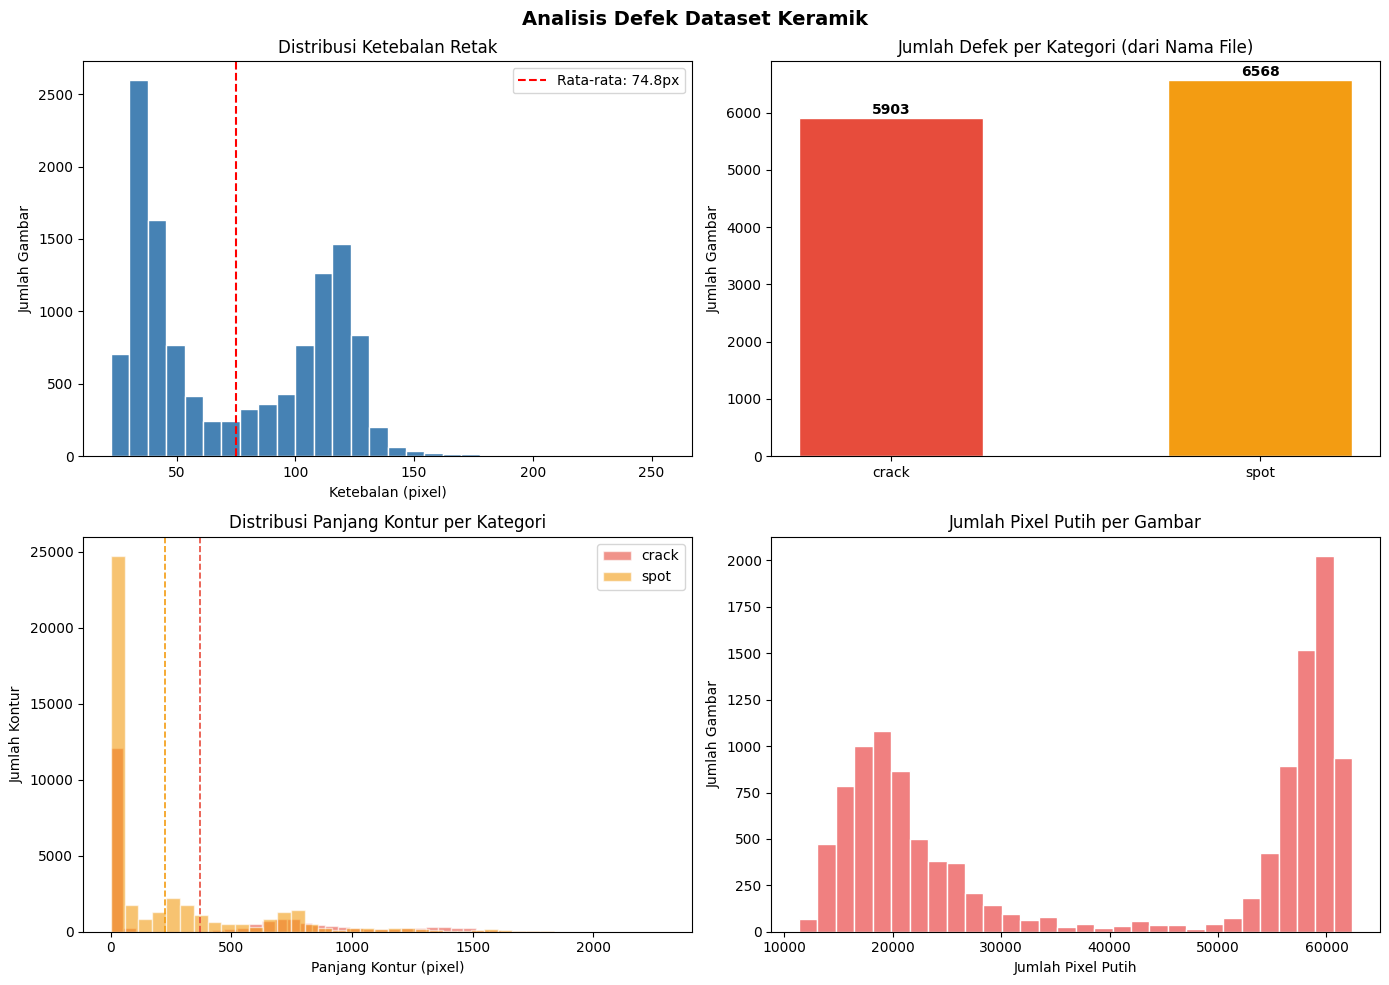

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Defek Dataset Keramik', fontsize=14, fontweight='bold')

# ── Plot 1: Distribusi Ketebalan ─────────────────────────────────────────────
axes[0, 0].hist(valid_thick, bins=30, color='steelblue', edgecolor='white')
axes[0, 0].axvline(avg_thick, color='red', linestyle='--',
                   label=f'Rata-rata: {avg_thick:.1f}px')
axes[0, 0].set_title('Distribusi Ketebalan Retak')
axes[0, 0].set_xlabel('Ketebalan (pixel)')
axes[0, 0].set_ylabel('Jumlah Gambar')
axes[0, 0].legend()

# ── Plot 2: Jumlah Defek per Kategori ────────────────────────────────────────
labels = [t for t in MAIN_TYPES if total_defects[t] > 0]
values = [total_defects[t] for t in labels]
colors = [CATEGORY_COLORS[t] for t in labels]
bars   = axes[0, 1].bar(labels, values, color=colors, edgecolor='white', width=0.5)
axes[0, 1].set_title('Jumlah Defek per Kategori (dari Nama File)')
axes[0, 1].set_ylabel('Jumlah Gambar')
for bar, val in zip(bars, values):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(values) * 0.01,
                    str(val), ha='center', fontweight='bold')

# ── Plot 3: Histogram Panjang Kontur per Kategori ────────────────────────────
for dtype in MAIN_TYPES:
    lens = lengths_per_category[dtype]
    if lens:
        axes[1, 0].hist(lens, bins=40, alpha=0.6,
                        color=CATEGORY_COLORS[dtype], edgecolor='white', label=dtype)
        axes[1, 0].axvline(np.mean(lens), color=CATEGORY_COLORS[dtype],
                           linestyle='--', linewidth=1.2)
axes[1, 0].set_title('Distribusi Panjang Kontur per Kategori')
axes[1, 0].set_xlabel('Panjang Kontur (pixel)')
axes[1, 0].set_ylabel('Jumlah Kontur')
axes[1, 0].legend()

# ── Plot 4: Jumlah Pixel Putih per Gambar (FIX #3: gunakan cache, tidak re-read) ─
white_pixel_counts = [r['white_pixels'] for r in per_image_results]
axes[1, 1].hist(white_pixel_counts, bins=30, color='lightcoral', edgecolor='white')
axes[1, 1].set_title('Jumlah Pixel Putih per Gambar')
axes[1, 1].set_xlabel('Jumlah Pixel Putih')
axes[1, 1].set_ylabel('Jumlah Gambar')

plt.tight_layout()
plt.show()


## 5. Persiapan Data Training
Label diambil dari fungsi `classify_by_path` yang sudah disatukan. Gambar 'unknown' difilter dengan peringatan eksplisit.

In [ ]:
# ── 1. FILTER & LABEL ──────────────────────────────────────────────────────────
# FIX #9: Tambahkan peringatan eksplisit jika banyak data yang gugur karena 'unknown'
valid_paths      = []
valid_labels_str = []

for path in image_paths:
    label = classify_by_path(path)
    if label != 'unknown':
        valid_paths.append(path)
        valid_labels_str.append(label)

dropped = len(image_paths) - len(valid_paths)
if dropped > 0:
    print(f"⚠️  {dropped} gambar digugurkan karena label 'unknown' "
          f"({dropped/len(image_paths)*100:.1f}% dari total valid)")

unique_classes   = sorted(set(valid_labels_str))
class_to_idx     = {cls: i for i, cls in enumerate(unique_classes)}
valid_labels_int = [class_to_idx[lbl] for lbl in valid_labels_str]
NUM_CLASSES      = len(unique_classes)

print(f"Kelas terdeteksi          : {unique_classes}")
print(f"Jumlah data untuk training: {len(valid_paths)}")

# ── 2. CUSTOM DATASET ────────────────────────────────────────────────────────
class CeramicDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# ── 3. TRANSFORM & DATALOADER ────────────────────────────────────────────────
# RAM FIX A: Resize ke 224 (bukan 518) — DINOv2 vit_small support multi-resolution.
# 518² = 268K pixel/gambar vs 224² = 50K pixel/gambar → hemat ~5x memori per batch.
# Jika akurasi kurang memuaskan, naikkan ke 336 atau 448 secara bertahap.
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset               = CeramicDataset(valid_paths, valid_labels_int, transform)
total_size                 = len(full_dataset)
train_size                 = int(0.8 * total_size)
val_size                   = total_size - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# RAM FIX B: Kurangi batch_size dari 32 → 16.
# Setiap batch di RAM: 16 × 3 × 224 × 224 × 4 bytes ≈ 145 MB (vs 580 MB dengan 32).
BATCH_SIZE  = 16
NUM_WORKERS = 0 if not torch.cuda.is_available() else min(4, os.cpu_count() or 1)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

print(f"Train: {train_size} | Val: {val_size}")
print(f"Batch size: {BATCH_SIZE} | Img size: {IMG_SIZE}px | Num workers: {NUM_WORKERS}")


Kelas terdeteksi          : ['crack', 'spot']
Jumlah data untuk training: 12471
Train: 9976 | Val: 2495
Batch size: 16 | Img size: 224px | Num workers: 0


## 6. Model DINOv2 & Training
- **FIX #6**: Ganti `while` loop dengan `for` loop yang idiomatik.
- **FIX #7**: `val_loss` kini dipakai sebagai dasar early stopping (lebih stabil dari akurasi).
- **FIX #11**: Tambahkan `CosineAnnealingLR` scheduler.

In [7]:
import gc
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS = 30
PATIENCE   = 5

# ── MODEL ─────────────────────────────────────────────────────────────────────
# RAM FIX D: Freeze semua backbone, hanya latih classifier head.
# DINOv2 vit_small punya ~22M parameter. Melatih semua parameter sekaligus
# menyimpan gradient untuk setiap parameter → sangat boros RAM.
# Dengan freeze backbone: hanya head (NUM_CLASSES × 384 weight) yang butuh gradient.
model = timm.create_model('vit_small_patch14_dinov2.lvd142m', pretrained=True, img_size=IMG_SIZE)

# Freeze semua layer backbone
for param in model.parameters():
    param.requires_grad = False

# Ganti & unfreeze hanya classifier head
if hasattr(model, 'reset_classifier'):
    model.reset_classifier(NUM_CLASSES)
else:
    in_features = getattr(model, 'num_features', None) or getattr(model, 'embed_dim', None)
    model.head  = nn.Linear(in_features, NUM_CLASSES)

# Pastikan head selalu trainable
for param in model.head.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

# Hanya optim parameter yang requires_grad (head saja)
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Parameter trainable : {sum(p.numel() for p in trainable_params):,}")
print(f"Parameter frozen    : {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(trainable_params, lr=1e-3)  # lr lebih tinggi karena hanya head
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

# ── TRAINING LOOP ─────────────────────────────────────────────────────────────
best_val_loss    = float('inf')
best_val_acc     = 0.0
patience_counter = 0

print('\nMemulai Training...')
print('='*50)

for epoch in range(1, MAX_EPOCHS + 1):

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    running_loss  = 0.0
    correct_train = 0
    total_train   = 0

    train_pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                      desc=f'Epoch {epoch}/{MAX_EPOCHS} [Train]')
    for step, (images, labels) in train_pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss  += loss.item()
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        train_pbar.set_postfix(loss=running_loss / (step + 1),
                               acc=100. * correct_train / total_train)

    train_acc = 100. * correct_train / total_train

    # ── VALIDATION ───────────────────────────────────────────────────────────
    model.eval()
    correct_val = 0
    total_val   = 0
    val_loss    = 0.0

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch}/{MAX_EPOCHS} [Val]')
        for images, labels in val_pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs         = model(images)
            val_loss       += criterion(outputs, labels).item()
            _, predicted    = torch.max(outputs, 1)
            total_val      += labels.size(0)
            correct_val    += (predicted == labels).sum().item()
            val_pbar.set_postfix(acc=100. * correct_val / total_val)

    current_val_acc = 100. * correct_val / total_val
    avg_val_loss    = val_loss / len(val_loader)

    scheduler.step()

    # RAM FIX E: Bebaskan memori tensor sisa setiap akhir epoch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f'\nRingkasan Epoch {epoch}:')
    print(f'  Train Acc  : {train_acc:.2f}%')
    print(f'  Val Acc    : {current_val_acc:.2f}%   Val Loss: {avg_val_loss:.4f}')
    print(f'  LR saat ini: {scheduler.get_last_lr()[0]:.2e}')
    print('-'*50)

    # ── CHECKPOINTING & EARLY STOPPING ───────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_val_acc  = current_val_acc
        torch.save(model.state_dict(), 'best_model_dinov2.pth')
        print(f'  🔥 Model terbaik disimpan! Val Loss: {best_val_loss:.4f} | Val Acc: {best_val_acc:.2f}%')
        patience_counter = 0
    else:
        patience_counter += 1
        print(f'  ⚠️  Val loss tidak membaik. Patience: {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\n[EARLY STOP] Berhenti setelah {PATIENCE} epoch tanpa perbaikan val loss.')
        break

print(f'\nTraining selesai. Model terbaik (val acc {best_val_acc:.2f}%) '
      f"tersimpan di 'best_model_dinov2.pth'.")


Parameter trainable : 770
Parameter frozen    : 21,628,800

Memulai Training...


Epoch 1/30 [Val]: 100%|██████████| 156/156 [05:28<00:00,  2.10s/it, acc=99.9]



Ringkasan Epoch 1:
  Train Acc  : 99.39%
  Val Acc    : 99.92%   Val Loss: 0.0035
  LR saat ini: 9.97e-04
--------------------------------------------------
  🔥 Model terbaik disimpan! Val Loss: 0.0035 | Val Acc: 99.92%


Epoch 2/30 [Val]: 100%|██████████| 156/156 [11:45<00:00,  4.52s/it, acc=99.9]



Ringkasan Epoch 2:
  Train Acc  : 99.97%
  Val Acc    : 99.92%   Val Loss: 0.0027
  LR saat ini: 9.89e-04
--------------------------------------------------
  🔥 Model terbaik disimpan! Val Loss: 0.0027 | Val Acc: 99.92%


...


Ringkasan Epoch 17:
  Train Acc  : 100.00%
  Val Acc    : 99.96%   Val Loss: 0.0014
  LR saat ini: 3.96e-04
--------------------------------------------------
  ⚠️  Val loss tidak membaik. Patience: 3/5


Epoch 18/30 [Val]: 100%|██████████| 156/156 [04:20<00:00,  1.67s/it, acc=100] 



Ringkasan Epoch 18:
  Train Acc  : 100.00%
  Val Acc    : 99.96%   Val Loss: 0.0015
  LR saat ini: 3.45e-04
--------------------------------------------------
  ⚠️  Val loss tidak membaik. Patience: 4/5


Epoch 19/30 [Val]: 100%|██████████| 156/156 [04:20<00:00,  1.67s/it, acc=100] 


Ringkasan Epoch 19:
  Train Acc  : 100.00%
  Val Acc    : 99.96%   Val Loss: 0.0013
  LR saat ini: 2.97e-04
--------------------------------------------------
  ⚠️  Val loss tidak membaik. Patience: 5/5

[EARLY STOP] Berhenti setelah 5 epoch tanpa perbaikan val loss.

Training selesai. Model terbaik (val acc 99.92%) tersimpan di 'best_model_dinov2.pth'.


In [ ]:
print("hello world")

In [ ]:
print(best_val_loss)

## 7. Evaluasi Model (Standalone)
Cell ini **tidak bergantung** pada variables dari cell training. Bisa dijalankan even jika kernel restart atau cache hilang. Model weights dimuat dari `best_model_dinov2.pth`.

In [ ]:
# ── SETUP: INFER CLASS MAPPING DARI FOLDER DATASET ──────────────────────────
import os
from pathlib import Path

dataset_root = Path('dataset')
classes = sorted([d.name for d in dataset_root.iterdir() if d.is_dir()])
class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
NUM_CLASSES = len(classes)

print(f"Classes terdeteksi: {classes}")
print(f"Class mapping: {class_to_idx}")
print(f"NUM_CLASSES: {NUM_CLASSES}\n")

# ── SETUP: RECREATE MODEL (SAME ARCHITECTURE AS TRAINING) ────────────────────
import torch
import torch.nn as nn
import timm
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from tqdm import tqdm
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224

# Model architecture (HARUS SAMA dengan training)
model = timm.create_model('vit_small_patch14_dinov2.lvd142m', pretrained=True, img_size=IMG_SIZE)

# Freeze backbone (seperti training)
for param in model.parameters():
    param.requires_grad = False

# Reset classifier head
if hasattr(model, 'reset_classifier'):
    model.reset_classifier(NUM_CLASSES)
else:
    in_features = getattr(model, 'num_features', None) or getattr(model, 'embed_dim', None)
    model.head = nn.Linear(in_features, NUM_CLASSES)

# Load best model weights
model.load_state_dict(torch.load('best_model_dinov2.pth', map_location=DEVICE))
model.to(DEVICE).eval()

print(f"Model loaded from 'best_model_dinov2.pth'")
print(f"Device: {DEVICE}\n")

# ── SETUP: TRANSFORM (SAME AS TRAINING) ──────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── SETUP: EVAL DATASET ──────────────────────────────────────────────────────
class EvalDataset(Dataset):
    """Dataset untuk evaluasi (menggunakan folder structure untuk label)."""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Collect semua gambar dari dataset (split by class)
eval_paths = []
eval_labels = []

for class_name, class_idx in class_to_idx.items():
    class_dir = dataset_root / class_name
    if not class_dir.exists():
        continue
    for file in class_dir.rglob('*'):
        if file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            eval_paths.append(str(file))
            eval_labels.append(class_idx)

print(f"Total images untuk eval: {len(eval_paths)}")
print(f"Class distribution: {np.bincount([l for l in eval_labels])}\n")

eval_dataset = EvalDataset(eval_paths, eval_labels, transform=transform)
eval_loader = DataLoader(eval_dataset, batch_size=16, shuffle=False, num_workers=0)

# ── EVALUASI ─────────────────────────────────────────────────────────────────
print("Menjalankan evaluasi...\n")

correct = 0
total = 0
all_preds = []
all_labels = []
per_class_correct = {i: 0 for i in range(NUM_CLASSES)}
per_class_total = {i: 0 for i in range(NUM_CLASSES)}

with torch.no_grad():
    for images, labels in tqdm(eval_loader, desc='Eval'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Per-class accuracy
        for pred, label in zip(preds, labels):
            per_class_total[label.item()] += 1
            if pred == label:
                per_class_correct[label.item()] += 1

overall_acc = 100 * correct / total

print("\n" + "="*60)
print("            HASIL EVALUASI MODEL")
print("="*60)
print(f"\nOverall Accuracy: {overall_acc:.2f}% ({correct}/{total})")

print(f"\nPer-Class Accuracy:")
print(f"{'Class':<12} {'Accuracy':>10} {'Count':>8}")
print(f"{'-'*30}")
for i, class_name in enumerate(classes):
    if per_class_total[i] > 0:
        acc = 100 * per_class_correct[i] / per_class_total[i]
        print(f"{class_name:<12} {acc:>10.2f}% {per_class_total[i]:>8}")

print(f"\n{'TOTAL':<12} {overall_acc:>10.2f}% {total:>8}")
print("="*60)